# Customer Segmentation for Targeted Marketing

## Business Problem
The marketing team currently sends the **same offers to every customer**, regardless of how much they spend, how often they buy, or how recently they've purchased. This leads to:
- Wasted marketing spend on customers unlikely to respond
- High-value customers not being rewarded or retained
- Low-engagement customers not being re-activated with the right incentive

**Goal:** Segment customers into meaningful groups based on **purchasing behavior (Recency, Frequency, Monetary)**, **Income**, and **Age**, so marketing can design a targeted offer strategy for each segment instead of a one-size-fits-all campaign.

## Approach
1. Clean and understand the raw data
2. Engineer RFM (Recency, Frequency, Monetary) + Income + Age features
3. Detect and handle outliers
4. Cluster customers with K-Means
5. Profile each segment (spending, channel use, campaign response)
6. Translate segments into concrete marketing actions (the **Business Solution**, at the end)


In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 2. Load & Understand the Data

In [220]:
df = pd.read_csv("customer_segmentation.csv")

In [221]:
df.shape

(2240, 29)

In [222]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [223]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [224]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [225]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [226]:
df.duplicated().sum()

np.int64(0)

**Findings from the checks above:**
- `Income` has ~24 missing values that need to be filled.
- `Dt_Customer` is stored as text and needs to be converted to a real date.
- No duplicate rows.


## 3. Data Cleaning

- Convert `Dt_Customer` to a proper datetime.
- Drop rows with unrealistic `Year_Birth` (e.g. 1893, 1900) — these are clearly data-entry errors, not real customers.
- Fill missing `Income` values with the column median (robust to the skew we'll see in the outlier check below).


In [227]:
# Convert Dt_Customer from text to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# Remove unrealistic birth years (data entry errors)
df = df[df['Year_Birth'] > 1930].copy()

In [228]:
# Fill missing Income with the median (only true NaNs are affected, not 0s)
df['Income'] = df['Income'].fillna(df['Income'].median())

## 4. Feature Engineering — RFM

We already have `Recency` (days since last purchase) in the raw data — a value of `0` here is a *real* signal ("bought today"), not a missing value, so we leave it untouched.

We still need to build:
- **Age** — from `Year_Birth`
- **Monetary** — total amount spent across all product categories
- **Frequency** — total number of purchases across all channels


**Age:** Using the most recent enrollment year in the dataset (`Dt_Customer.dt.year.max()`) as a consistent proxy for "today," so every customer is aged on the same scale rather than by their individual signup date.

In [229]:
# Create: age column
df['Age'] = df['Dt_Customer'].dt.year.max()- df['Year_Birth']

In [230]:
# Monetary: total spend across all product categories
df['Monetary'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts']
    + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)

In [231]:
# Frequency: total number of purchases across all channels
df['Frequency'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

## 5. Selecting Features for Clustering

In [232]:
df_kmeans = df[['Recency', 'Frequency', 'Monetary', 'Income', 'Age']].copy()
df_kmeans.head()

,Recency,Frequency,Monetary,Income,Age
0,58,22,1617,58138.0,57
1,38,4,27,46344.0,60
2,26,20,776,71613.0,49
3,26,6,53,26646.0,30
4,94,14,422,58293.0,33


## 6. Outlier Detection

K-Means uses Euclidean distance, so a handful of extreme values (e.g. an income of 666,666) can pull cluster centers away from where the *majority* of customers actually sit. We check skew, histograms, and boxplots for each feature first.


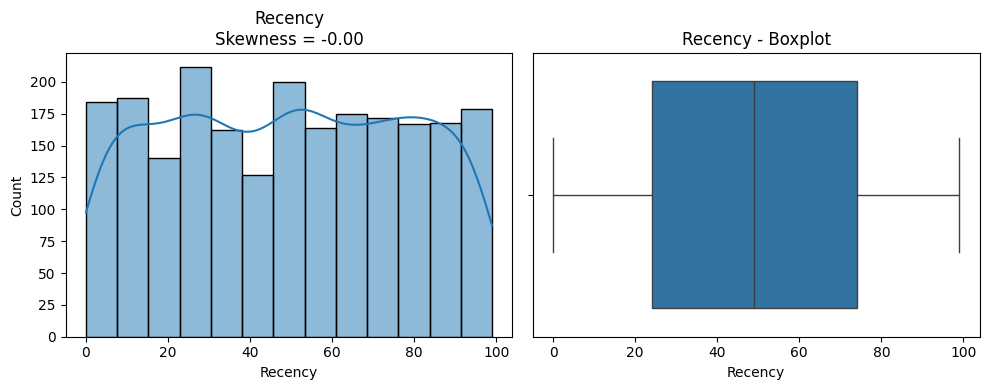

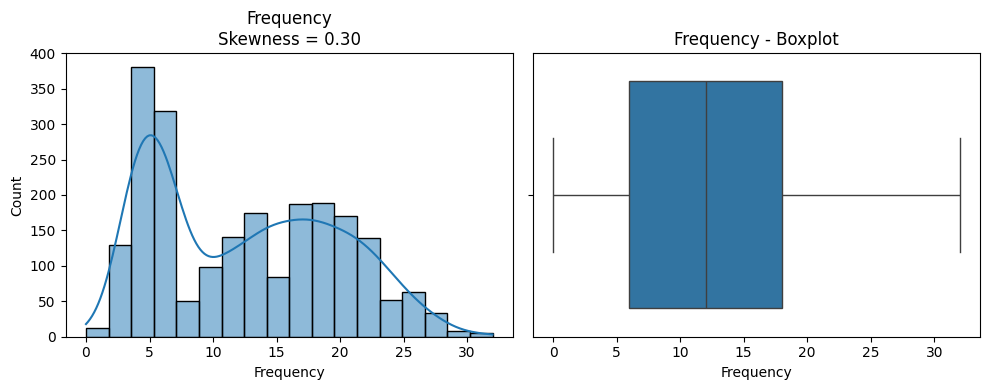

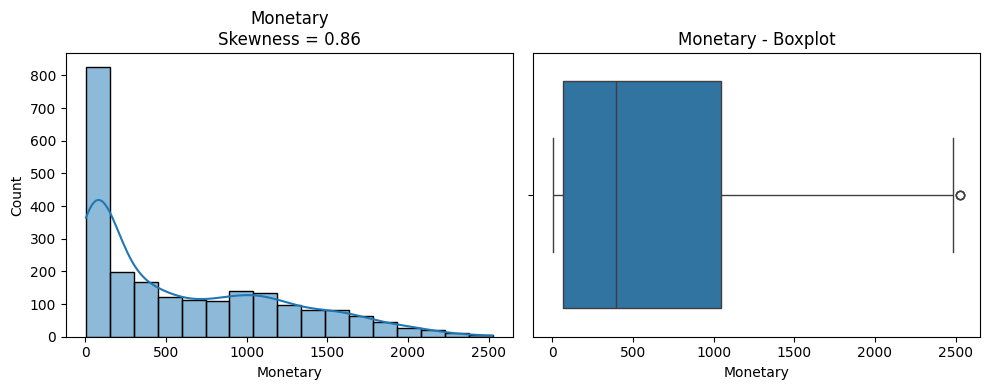

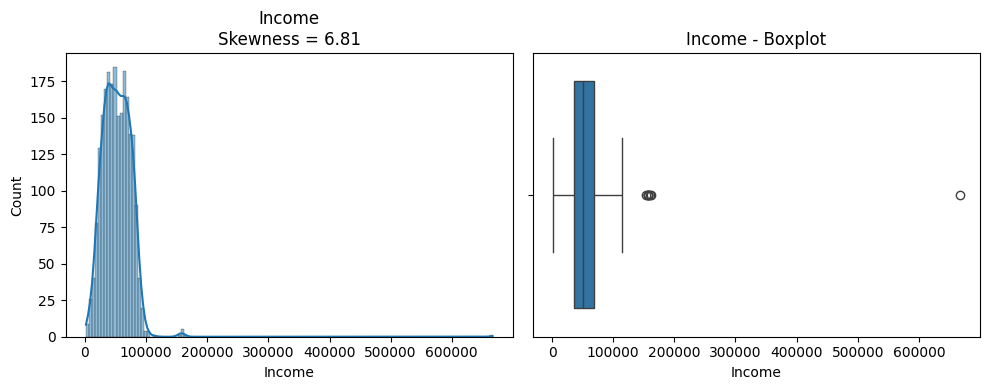

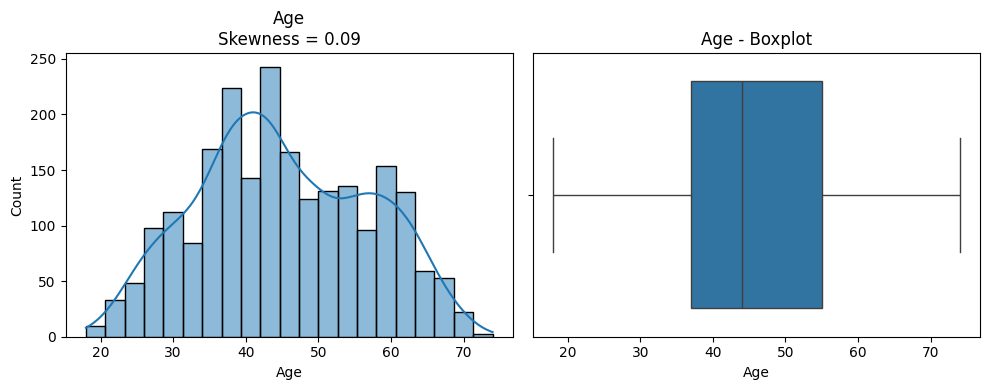

In [233]:
for col in df_kmeans.columns:

    skew = df_kmeans[col].skew()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram
    sns.histplot(df_kmeans[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col}\nSkewness = {skew:.2f}')

    # Boxplot
    sns.boxplot(x=df_kmeans[col], ax=axes[1])
    axes[1].set_title(f'{col} - Boxplot')

    plt.tight_layout()
    plt.show()

### Removing outliers (IQR method)

> **Caveat to keep in mind:** `Income` and `Monetary` are naturally right-skewed — a small number of customers genuinely earn/spend a lot more than everyone else. Statistically flagging them as "outliers" and dropping them risks removing your **most valuable customers** right before you try to identify a high-value segment. Always check *how many* rows this removes (below) before committing to it. If it's a large share of the data, consider capping values instead of dropping the rows, or using an outlier-robust method (e.g. DBSCAN) for comparison.


In [234]:
Q1 = df_kmeans.quantile(0.25)
Q3 = df_kmeans.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (df_kmeans < lower_bound) | (df_kmeans > upper_bound)
outliers.sum()

,0
Recency,0
Frequency,0
Monetary,3
Income,8
Age,0


Dropping the outliers

In [235]:
df_kmeans = df_kmeans[~outliers.any(axis=1)].copy()
df_kmeans.shape

(2226, 5)

## 7. Scaling the Features

In [236]:
scaler = StandardScaler()
df_kmeans_scaled = scaler.fit_transform(df_kmeans)

## 8. Choosing the Number of Clusters (k)

- **Elbow method (WCSS)** — where does adding more clusters stop reducing within-cluster variance much further?


In [237]:
wcss = []
k_range = range(2, 11)
for k in k_range:
  kmean = KMeans(n_clusters=k, random_state=42)
  kmean.fit(df_kmeans_scaled)
  wcss.append(kmean.inertia_)

In [238]:
wcss

[6399.46788185313,
 5536.59470896538,
 4816.4580443144,
 4148.170147950539,
 3682.14580633694,
 3392.311187140683,
 3135.6378027128544,
 2913.118261711743,
 2824.278752348064]

Text(0, 0.5, 'WCSS')

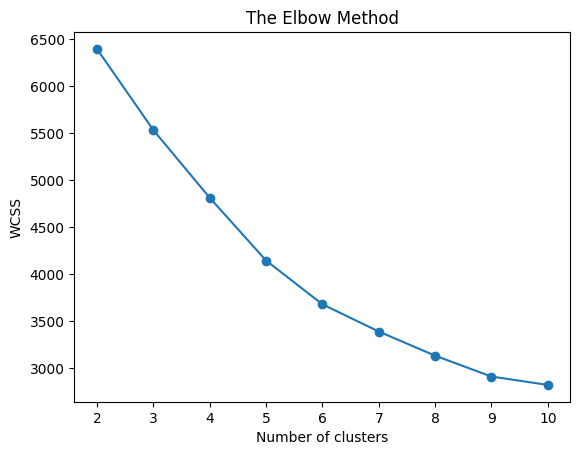

In [239]:
plt.plot(k_range, wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

**Decision:** Pick the smallest `k` where the elbow chart clearly flattens out **and** the silhouette score is still reasonably high. Based on this data, **k = 5** balances compact, well-separated clusters with an interpretable number of segments

## 9. Fitting the Final Model & Assigning Segments

In [240]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df_kmeans['Cluster'] = kmeans_final.fit_predict(df_kmeans_scaled)
df_kmeans['Cluster'].value_counts().sort_index()

,count
Cluster,
0,439
1,441
2,495
3,361
4,490


## 10. Visualizing Segments with PCA

In [241]:
pca = PCA(n_components=2)
df_kmeans_pca = pca.fit_transform(df_kmeans_scaled)

df_kmeans['PCA1'] = df_kmeans_pca[:, 0]
df_kmeans['PCA2'] = df_kmeans_pca[:, 1]

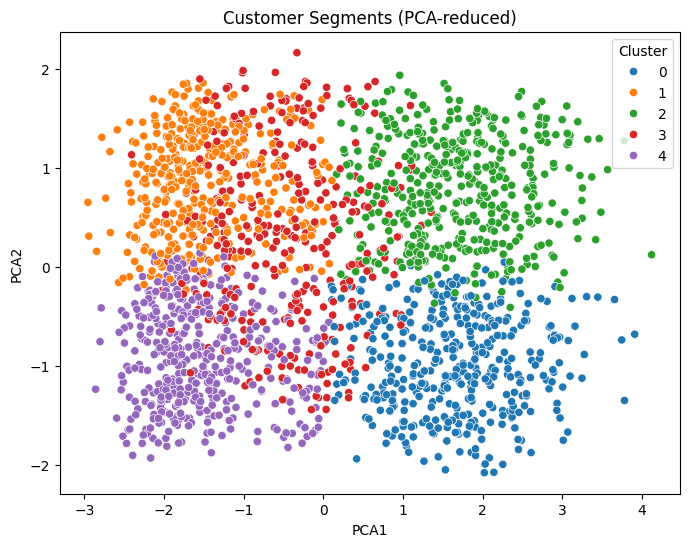

In [242]:
# Plotting
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_kmeans, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title('Customer Segments (PCA-reduced)')
plt.show()

## 11. Merging Segments Back into the Full Dataset

In [243]:
df_final = df.loc[df_kmeans.index].copy()
df_final[['Cluster', 'PCA1', 'PCA2']] = df_kmeans[['Cluster', 'PCA1', 'PCA2']]
df_final.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Monetary,Frequency,Cluster,PCA1,PCA2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,57,1617,22,2,2.082500,0.408351
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,60,27,4,3,-1.147667,-0.017109
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,49,776,20,0,1.352765,-0.778064
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,30,53,6,4,-1.971857,-0.965421
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,33,422,14,1,-0.033360,1.279159


## 12. Profiling Each Segment

This is where we answer the original business question: *what does each segment actually look like, and how do they behave?*


Core RFM + demographic profile

In [244]:
df_final.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary', 'Income', 'Age']
].mean().round(1)

,Recency,Frequency,Monetary,Income,Age
Cluster,,,,,
0,22.5,19.7,1183.3,70963.1,45.7
1,75.9,6.5,130.7,33965.3,38.7
2,73.3,19.4,1218.2,70651.4,47.3
3,50.5,9.9,278.2,46965.7,58.3
4,23.5,6.5,125.8,34147.2,38.5


Campaign response by segment

In [245]:
df_final.groupby('Cluster')[
    [
        'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response'
    ]
].mean().round(2)

,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
Cluster,,,,
0,0.09,0.13,0.17,0.28
1,0.05,0.01,0.00,0.05
2,0.07,0.15,0.17,0.16
3,0.05,0.07,0.00,0.09
4,0.09,0.01,0.00,0.16


Channel prefrence by segment

In [246]:
df_final.groupby('Cluster')[
    [
        'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases'
    ]
].mean().round(1)

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Cluster,,,
0,6.1,5.0,8.7
1,2.5,0.6,3.4
2,5.7,5.2,8.5
3,3.7,1.5,4.7
4,2.5,0.6,3.4


Product Category prefrence by segment

In [247]:
df_final.groupby('Cluster')[
    [
        'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
        'MntSweetProducts', 'MntGoldProds'
    ]
].mean().round(1)

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,596.3,52.8,335.4,73.5,53.6,71.7
1,51.0,7.3,34.5,9.9,7.2,20.9
2,619.1,51.4,342.6,74.6,55.0,75.5
3,159.7,9.7,55.1,15.8,9.9,28.1
4,56.9,6.0,28.3,8.9,5.4,20.3


 Business Solution — From Segments to Actions

Match each cluster's numbers from section 12 to the closest pattern below, rename it with something descriptive, and use the channel/product tables to decide **how** and **what** to offer.

| RFM pattern | Likely persona | Suggested marketing action |
|---|---|---|
| High Monetary, High Frequency, low Recency | Loyal / VIP customers | Reward with a loyalty program, early access, upsell premium products |
| High Monetary, low Frequency, high Recency | At-risk high spenders | Personalized win-back offer before they churn |
| Low Monetary, high Frequency | Frequent small spenders | Bundle deals / cross-sell to grow basket size |
| Low Monetary, low Frequency, high Recency | Low engagement / churn risk | Low-cost reactivation email or discount |

**Example of how to use this:**
- If a segment shows high `NumStorePurchases` but low `NumWebPurchases`, prioritize in-store promotions or mailers over email for that group.
- If a segment's biggest `Mnt*` category is Wine, lead with wine-related offers/cross-sells for them specifically, rather than a generic discount.
- If a segment has a high `AcceptedCmp` rate for a specific past campaign, that channel/offer type has proven to work on them — repeat and expand it.


 Conclusion

We cleaned the raw data, engineered RFM + demographic features, removed statistical outliers (with an explicit check on how much data that removed), and used K-Means (validated with both the elbow method and silhouette score) to split customers into 4 segments. Profiling each segment across spending, channel, and campaign-response behavior turns "Segment 0, 1, 2, 3, 4" into an actionable marketing plan.
